In [1]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage as ndi


In [2]:
file_path = Path("data") / "strain_wave_longitudinal_phi_scan.pkl"

with file_path.open("rb") as f:
    data = pickle.load(f)

phi_values_deg = np.asarray(data["phi_values_deg"], dtype=float)
phi_values_rad = np.asarray(data["phi_values_rad"], dtype=float)
frames = np.asarray(data["im_stack"], dtype=float)
frames_ref = np.asarray(data["im_ref_stack"], dtype=float)
rulers = data["rulers"]
x_profile_m = np.asarray(data["x_profile_m"], dtype=float)
eps_profile = np.asarray(data["eps_profile"], dtype=float)

det_x_um = np.asarray(rulers[0], dtype=float) * 1e6
det_y_um = np.asarray(rulers[1], dtype=float) * 1e6

print(frames.shape)
print(frames_ref.shape)


(21, 200, 5)
(21, 200, 5)


In [3]:
def compute_COM_robust(frames, varying_arr, sigma=3, min_total_intensity=1e-12, quantile_floor=0.02, floor_scale=0.02):
    frames_filt = np.stack([ndi.gaussian_filter(frame, sigma) for frame in frames])
    frames_filt = np.clip(frames_filt, 0.0, None)
    varying = np.asarray(varying_arr, dtype=float)[:, None, None]

    weighted_sum = np.sum(varying * frames_filt, axis=0)
    total = np.sum(frames_filt, axis=0)

    positive = total[np.isfinite(total) & (total > 0)]
    if positive.size > 0:
        adaptive_floor = np.quantile(positive, quantile_floor) * floor_scale
    else:
        adaptive_floor = min_total_intensity

    threshold = max(float(min_total_intensity), float(adaptive_floor))
    valid = total > threshold

    com = np.full(total.shape, np.nan, dtype=float)
    com[valid] = weighted_sum[valid] / total[valid]
    return com, valid, threshold

def collapse_profile_with_support(map_2d, min_valid_fraction=0.35):
    valid_counts = np.sum(np.isfinite(map_2d), axis=1)
    valid_fraction = valid_counts / map_2d.shape[1]
    profile = np.full(map_2d.shape[0], np.nan, dtype=float)
    keep = valid_fraction >= min_valid_fraction
    profile[keep] = np.nanmean(map_2d[keep], axis=1)
    return profile, valid_fraction


In [4]:
phi_com, phi_valid, phi_thr = compute_COM_robust(frames, phi_values_rad, sigma=3)
phi_com_ref, phi_valid_ref, phi_thr_ref = compute_COM_robust(frames_ref, phi_values_rad, sigma=3)

phi_shift_raw = phi_com - phi_com_ref
valid_mask = phi_valid & phi_valid_ref & np.isfinite(phi_shift_raw)
phi_shift = np.where(valid_mask, phi_shift_raw, np.nan)
phi_shift_deg = np.rad2deg(phi_shift)
phi_shift_centered_deg = phi_shift_deg - np.nanmean(phi_shift_deg)

print("COM threshold (strained / ref):", float(phi_thr), float(phi_thr_ref))
print("Valid COM fraction:", float(np.mean(valid_mask)))
print("phi_shift_deg min/max:", float(np.nanmin(phi_shift_deg)), float(np.nanmax(phi_shift_deg)))


COM threshold (strained / ref): 13.361900087830163 69.31424162945426
Valid COM fraction: 1.0
phi_shift_deg min/max: -7.106526499062796e-07 7.449893222937937e-05


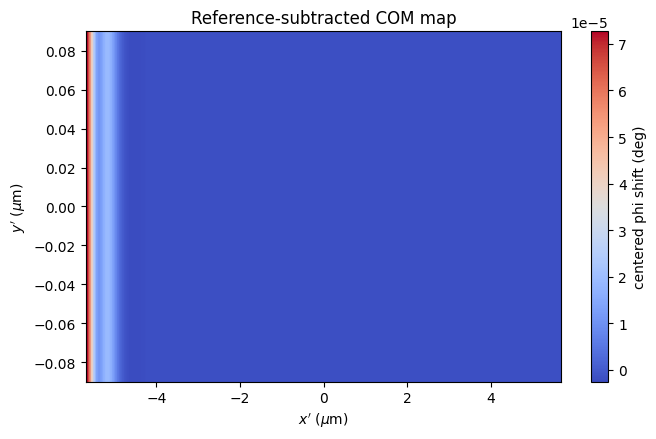

In [5]:
plt.figure(figsize=(7, 4.5))
plt.imshow(
    phi_shift_centered_deg.T,
    origin="lower",
    extent=[det_x_um.min(), det_x_um.max(), det_y_um.min(), det_y_um.max()],
    aspect="auto",
    cmap="coolwarm",
)
plt.xlabel(r"$x'$ ($\mu$m)")
plt.ylabel(r"$y'$ ($\mu$m)")
plt.colorbar(label="centered phi shift (deg)")
plt.title("Reference-subtracted COM map")
plt.tight_layout()
plt.show()


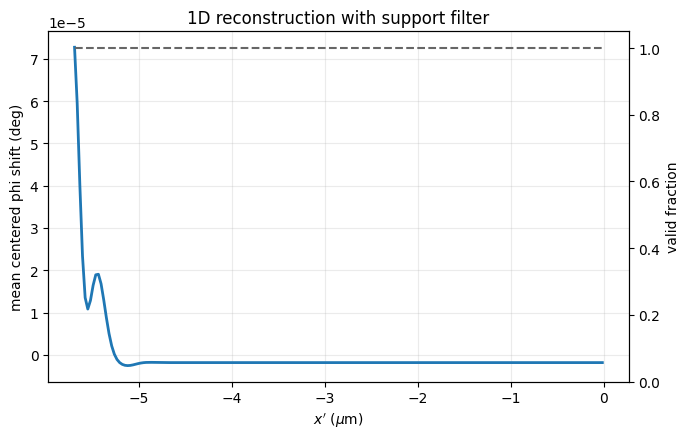

In [7]:
mean_phi_shift_deg, valid_fraction = collapse_profile_with_support(phi_shift_centered_deg, min_valid_fraction=0.35)

# Create x-axis that matches the length of the collapsed profile
x_axis = det_x_um[:len(mean_phi_shift_deg)]

fig, ax1 = plt.subplots(figsize=(7, 4.5))
ax1.plot(x_axis, mean_phi_shift_deg, lw=2)
ax1.set_xlabel(r"$x'$ ($\mu$m)")
ax1.set_ylabel("mean centered phi shift (deg)")
ax1.grid(alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(x_axis, valid_fraction, "--", color="0.4", lw=1.5)
ax2.set_ylabel("valid fraction")
ax2.set_ylim(0, 1.05)

plt.title("1D reconstruction with support filter")
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(6.5, 4))
plt.plot(x_profile_m * 1e6, eps_profile, lw=2)
plt.xlabel("distance from sample face along propagation direction (um)")
plt.ylabel("strain")
plt.title("Input longitudinal strain profile")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()
